In [1]:
#Packages
import pandas as pd
import re
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Cleaning
def clean_and_normalize_speaker_text(text):
    """Purifies dialogue rows by removing markdown noise and excessive whitespace."""
    if not isinstance(text, str) or pd.isna(text):
        return ""
    #Strips URL structures and HTML artifacts from transcript exports
    cleaned = re.sub(r'https?://\S+|www\.\S+', '', text)
    cleaned = re.sub(r'<.*?>', '', cleaned)
    cleaned = re.sub(r'\s+', ' ', cleaned)
    return cleaned.strip()

#Input Structuring
def process_speaker_row(ticker, speaker, role, speaker_text, max_words=380):
   
    clean_ticker = str(ticker).strip().upper()
    clean_speaker = str(speaker).strip() if pd.notna(speaker) else "Unknown Speaker"
    clean_role = str(role).strip() if pd.notna(role) else "Participant"
    
    #Constructs an informative title header natively from row metadata
    constructed_title = f"{clean_ticker} Call - {clean_speaker} ({clean_role})"
    
    raw_text = clean_and_normalize_speaker_text(speaker_text)
    if not raw_text:
        return ""
        
    words = raw_text.split(' ')
    
    #Conditional Check: If row is short, pass it through natively
    if len(words) <= max_words:
        return f"TITLE: {constructed_title} | SPEAKER_CONTEXT: {raw_text}"
        
    #Fallback Path: Handles long rows by slicing them
    sliced_words = words[:max_words]
    sliced_text = " ".join(sliced_words)
    return f"TITLE: {constructed_title} | SLICED_SPEAKER_CONTEXT: {sliced_text}"

In [3]:
#Processing
def transcript_pipeline(df, ticker_col='ticker', speaker_col='speaker', role_col='role', text_col='text'):

    df['finbert_input'] = df.apply(
        lambda row: process_speaker_row(
            ticker=row[ticker_col],
            speaker=row[speaker_col],
            role=row[role_col],
            speaker_text=row[text_col],
            max_words=380  #Safe boundary limit protecting against the 512 token wall
        ), axis=1
    )
    
    #Drops empty rows
    initial_len = len(df)
    df = df[df['finbert_input'] != ""].reset_index(drop=True)

In [4]:
#Data - Cleaned Transcripts Data
df_granular = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\ECT_Granular.csv")

In [5]:
#Execution
transcript_pipeline(df_granular)

In [6]:
#Validating Random text in the Dataset - df_granular
import random

sample_texts = random.sample(
    range(len(df_granular)), 2
)

for text in sample_texts:

    print("\nRaw Text:\n")
    print(df_granular.loc[text, 'text'][:700])

    print("\nProcessed Text:\n")
    print(df_granular.loc[text, 'finbert_input'][:700])


Raw Text:

So Craig, it's a good question. I think it's hard to put an exact number, but there are some, I think, very positive signs. The fact that we have $19 billion committed at the end of the quarter is a good forward indicator of a lot of activity. I would say that just the volume of what we're seeing across our business, our equity strategies, is picking up. We did this last quarter, our first growth deal in a while, buying an ERP software business in Israel. We're seeing good activity in our secondaries business, that has clearly picked up year-on-year. I think double the activity over last year's level. Infrastructure quite busy. Real estate a little more episodic, but we are definitely leanin

Processed Text:

TITLE: BX Call - Jon Gray (executive) | SPEAKER_CONTEXT: So Craig, it's a good question. I think it's hard to put an exact number, but there are some, I think, very positive signs. The fact that we have $19 billion committed at the end of the quarter is a good forward 

In [7]:
#Adding Processed word counts
df_granular['finbert_input_len'] = df_granular['finbert_input'].apply(lambda x:len(x.split()))

In [8]:
#Counts Statistics
display(df_granular['finbert_input_len'].describe().loc[['min', 'mean', 'max']])

min      13.000000
mean    124.166518
max     391.000000
Name: finbert_input_len, dtype: float64

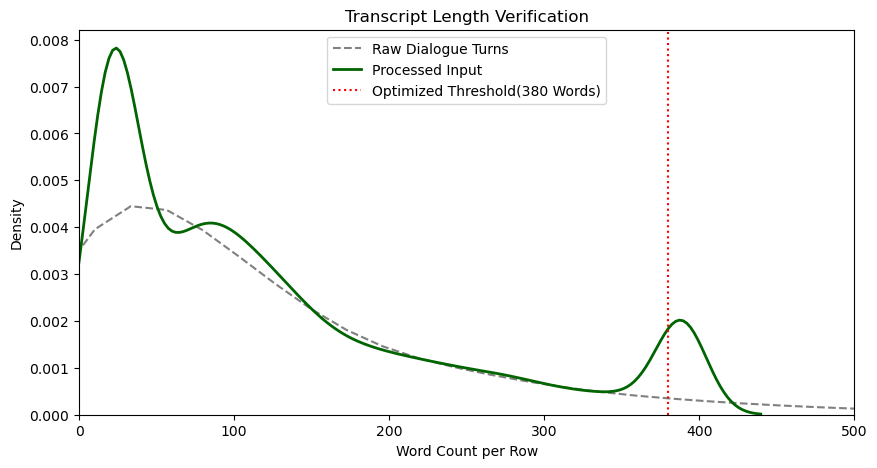

In [9]:
#length of the original text vs the processed text
plt.figure(figsize=(10, 5))
sns.kdeplot(df_granular['turn_word_count'], label='Raw Dialogue Turns', color='gray', linestyle='--')
sns.kdeplot(df_granular['finbert_input_len'], label='Processed Input', color='darkgreen', lw=2)
plt.axvline(x=380, color='red', linestyle=':', label='Optimized Threshold(380 Words)')
plt.xlim(0, 500)
plt.title('Transcript Length Verification', fontsize=12)
plt.xlabel('Word Count per Row')
plt.ylabel('Density')
plt.legend()
plt.savefig('ECT_length_verification.png', dpi=300)
plt.show()

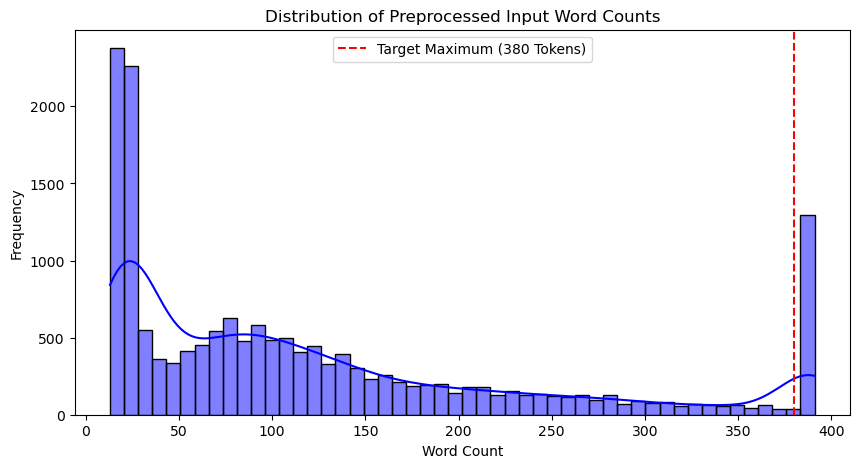

In [10]:
#Word count distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_granular['finbert_input_len'], bins=50, kde=True, color='blue')
plt.axvline(x=380, color='red', linestyle='--', label='Target Maximum (380 Tokens)')
plt.title('Distribution of Preprocessed Input Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('ECT_input_distribution.png', dpi=300)
plt.show()